In [89]:
# Unemployment Prediction 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

In [90]:
df= pd.read_csv(r"Unemployment in India.csv")

In [91]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [92]:
df.shape

(768, 7)

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [94]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [95]:
df.columns.tolist()

['Region',
 ' Date',
 ' Frequency',
 ' Estimated Unemployment Rate (%)',
 ' Estimated Employed',
 ' Estimated Labour Participation Rate (%)',
 'Area']

In [96]:
# check missing values
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [97]:
df= df.drop_duplicates()

In [98]:
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (741, 7)


In [99]:
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,29-02-2020,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban


In [100]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [101]:
df["Estimated Unemployment Rate (%)"] = pd.to_numeric(
    df["Estimated Unemployment Rate (%)"],
    errors="coerce"
)

df["Estimated Employed"] = pd.to_numeric(
    df["Estimated Employed"],
    errors="coerce"
)

df["Estimated Labour Participation Rate (%)"] = pd.to_numeric(
    df["Estimated Labour Participation Rate (%)"],
    errors="coerce"
)

In [102]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")

print(df["Date"].head())

0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]


In [103]:
df[df.isnull().any(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [104]:
df = df.dropna()

In [105]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [106]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September


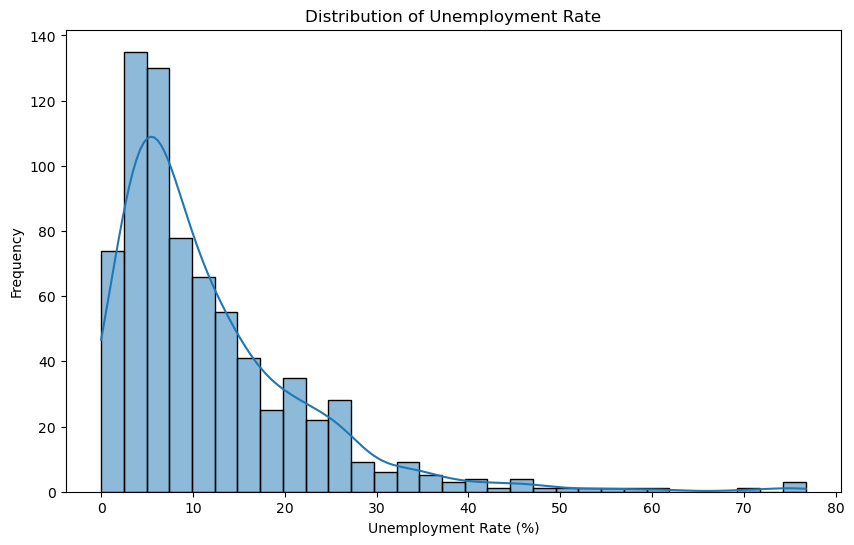

In [107]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Estimated Unemployment Rate (%)"],
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")

plt.show()

In [108]:
unemployment = df["Estimated Unemployment Rate (%)"]

print("Average unemployment:",
      unemployment.mean())

print("Maximum unemployment:",
      unemployment.max())

print("Minimum unemployment:",
      unemployment.min())

print("Standard deviation:",
      unemployment.std())

Average unemployment: 11.787945945945946
Maximum unemployment: 76.74
Minimum unemployment: 0.0
Standard deviation: 10.721298373157783


In [109]:
monthly = (
    df.groupby("Date")["Estimated Unemployment Rate (%)"]
      .mean()
      .reset_index()
)

monthly.head()

,Date,Estimated Unemployment Rate (%)
0,2019-05-31,8.874259
1,2019-06-30,9.303333
2,2019-07-31,9.033889
3,2019-08-31,9.637925
4,2019-09-30,9.051731


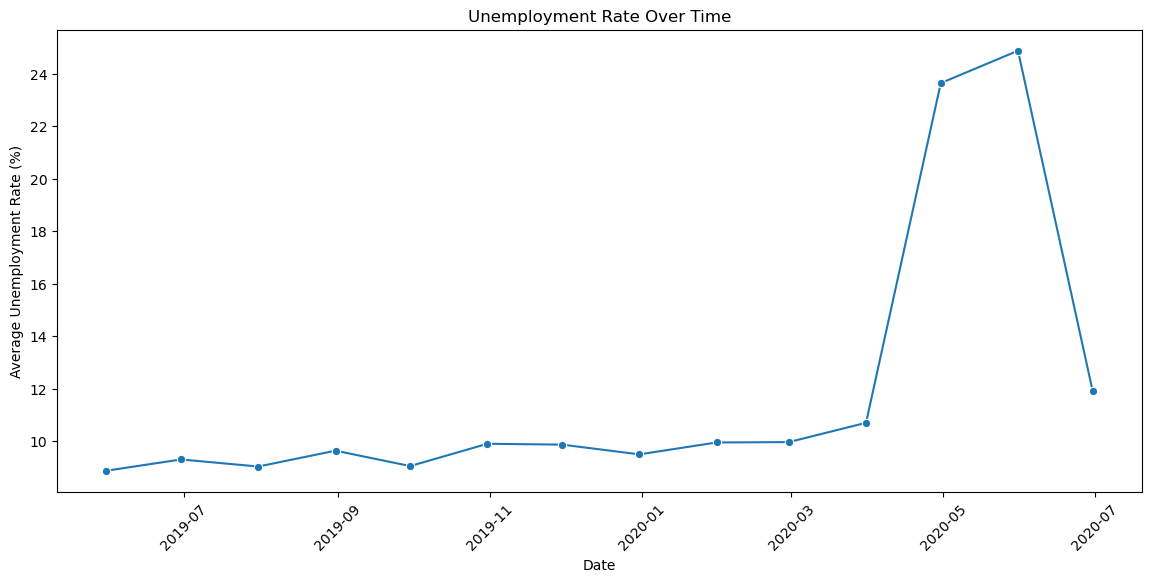

In [110]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o"
)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

In [111]:
df["COVID_Period"] = np.where(
    df["Date"] >= "2020-04-01",
    "COVID Period",
    "Pre-COVID"
)

df[["Date", "COVID_Period"]].head()

,Date,COVID_Period
0,2019-05-31,Pre-COVID
1,2019-06-30,Pre-COVID
2,2019-07-31,Pre-COVID
3,2019-08-31,Pre-COVID
4,2019-09-30,Pre-COVID


In [112]:
covid_analysis = (
    df.groupby("COVID_Period")
      ["Estimated Unemployment Rate (%)"]
      .mean()
      .reset_index()
)

covid_analysis

,COVID_Period,Estimated Unemployment Rate (%)
0,COVID Period,20.194342
1,Pre-COVID,9.614864


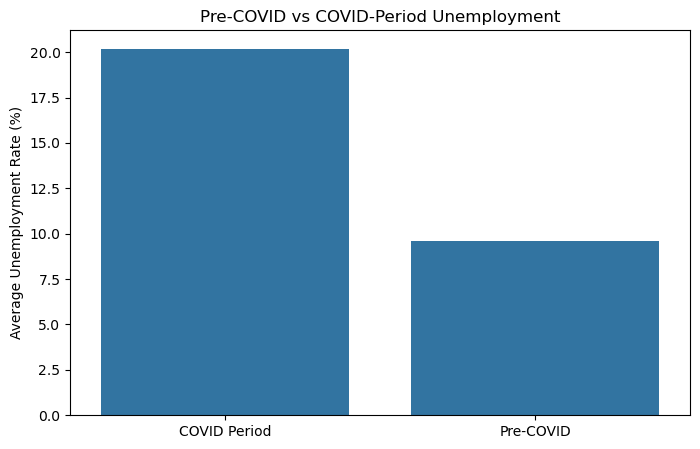

In [113]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=covid_analysis,
    x="COVID_Period",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Pre-COVID vs COVID-Period Unemployment")
plt.xlabel("")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

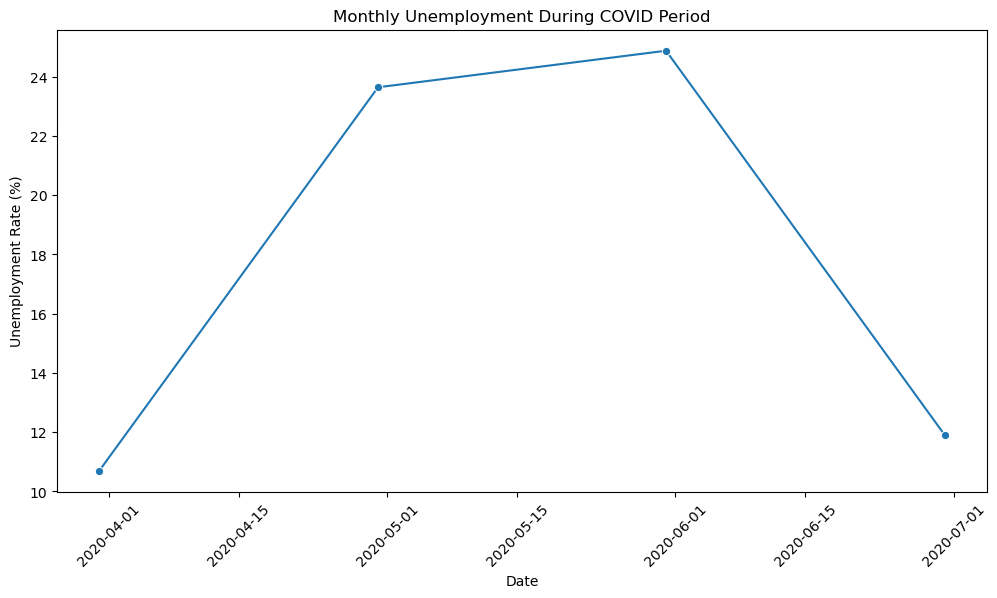

In [114]:
covid_monthly = (
    df[df["Date"] >= "2020-03-01"]
    .groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=covid_monthly,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    marker="o"
)

plt.title("Monthly Unemployment During COVID Period")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

In [115]:
region_analysis = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
      .mean()
      .sort_values(ascending=False)
)

region_analysis

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

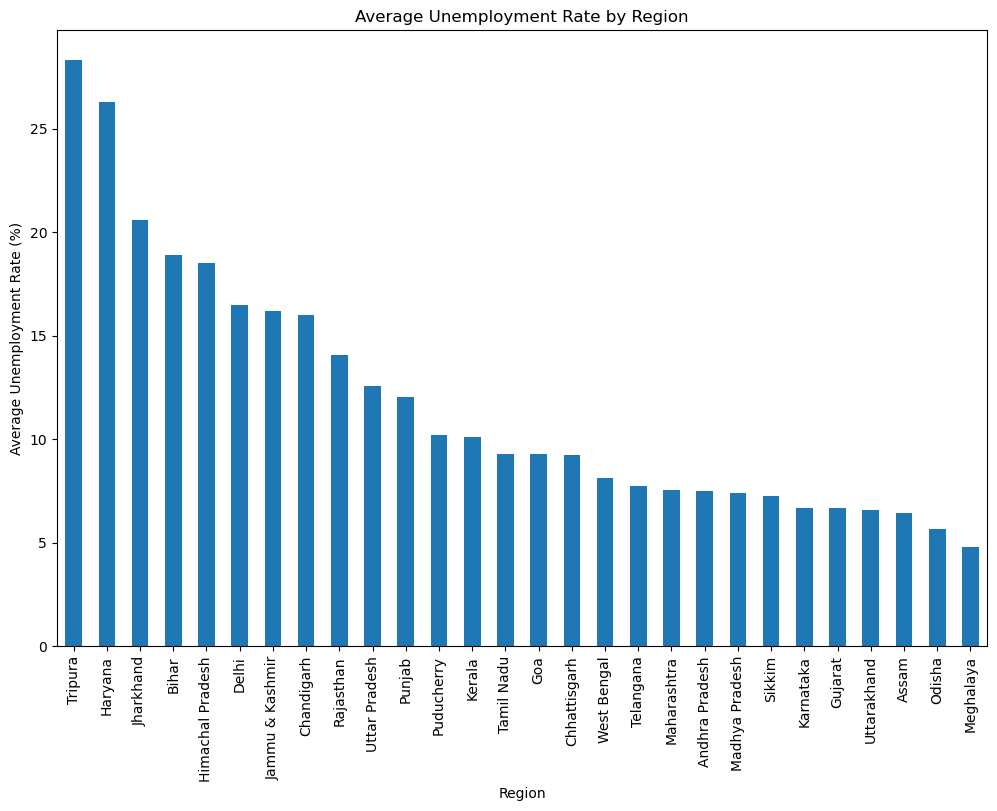

In [116]:
plt.figure(figsize=(12,8))

region_analysis.plot(kind="bar")

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=90)

plt.show()

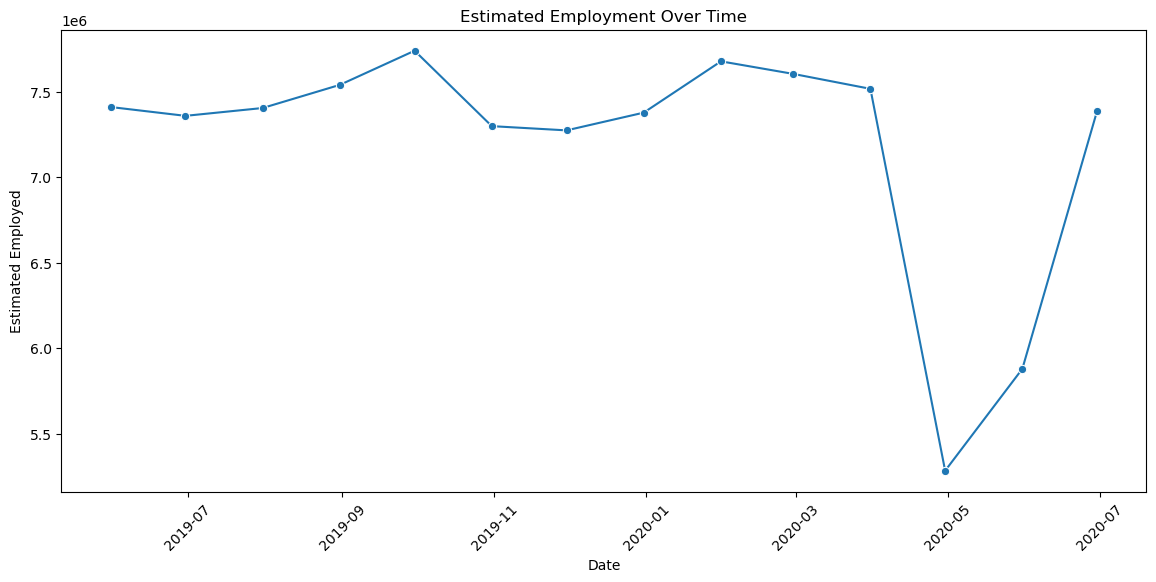

In [117]:
employment_monthly = (
    df.groupby("Date")["Estimated Employed"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=employment_monthly,
    x="Date",
    y="Estimated Employed",
    marker="o"
)

plt.title("Estimated Employment Over Time")
plt.xlabel("Date")
plt.ylabel("Estimated Employed")

plt.xticks(rotation=45)

plt.show()

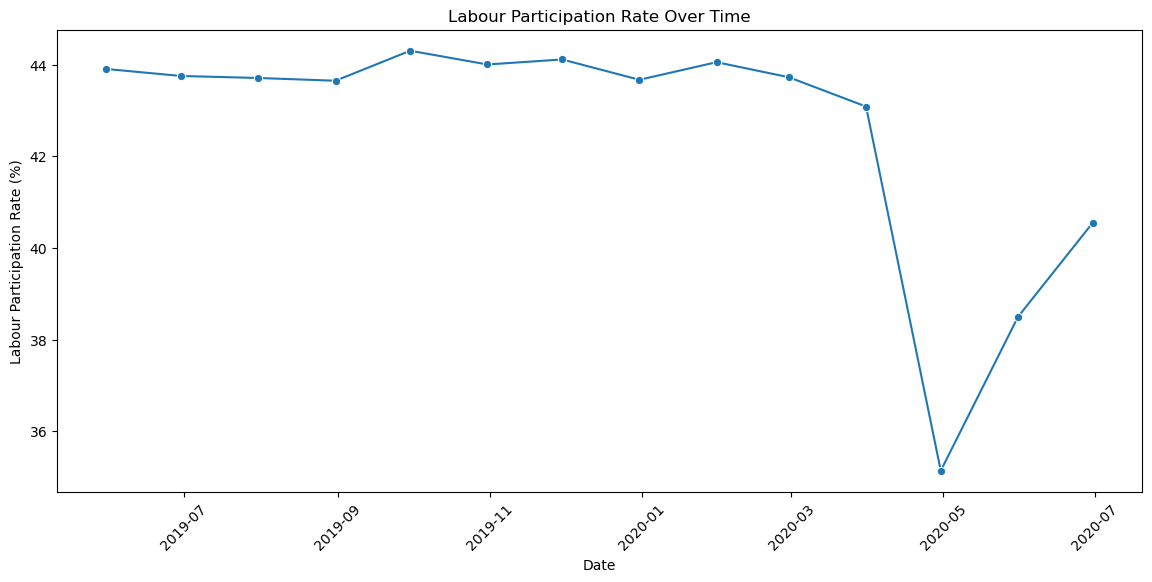

In [118]:
participation = (
    df.groupby("Date")
      ["Estimated Labour Participation Rate (%)"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=participation,
    x="Date",
    y="Estimated Labour Participation Rate (%)",
    marker="o"
)

plt.title("Labour Participation Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Labour Participation Rate (%)")

plt.xticks(rotation=45)

plt.show()

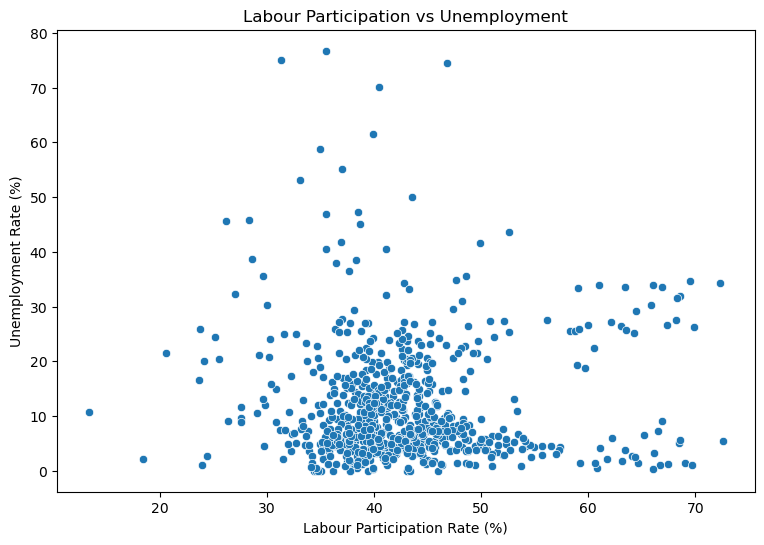

In [119]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Estimated Labour Participation Rate (%)",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Labour Participation vs Unemployment")
plt.xlabel("Labour Participation Rate (%)")
plt.ylabel("Unemployment Rate (%)")

plt.show()

In [120]:
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation = df[numeric_columns].corr()

print(correlation)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.222876   
Estimated Labour Participation Rate (%)                         0.002558   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.222876   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)            0.011300   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                         0.002558  
Estimated Employed                                                      0.011300  
Estimated Labour Participation Rate (%)                                 1.000000  


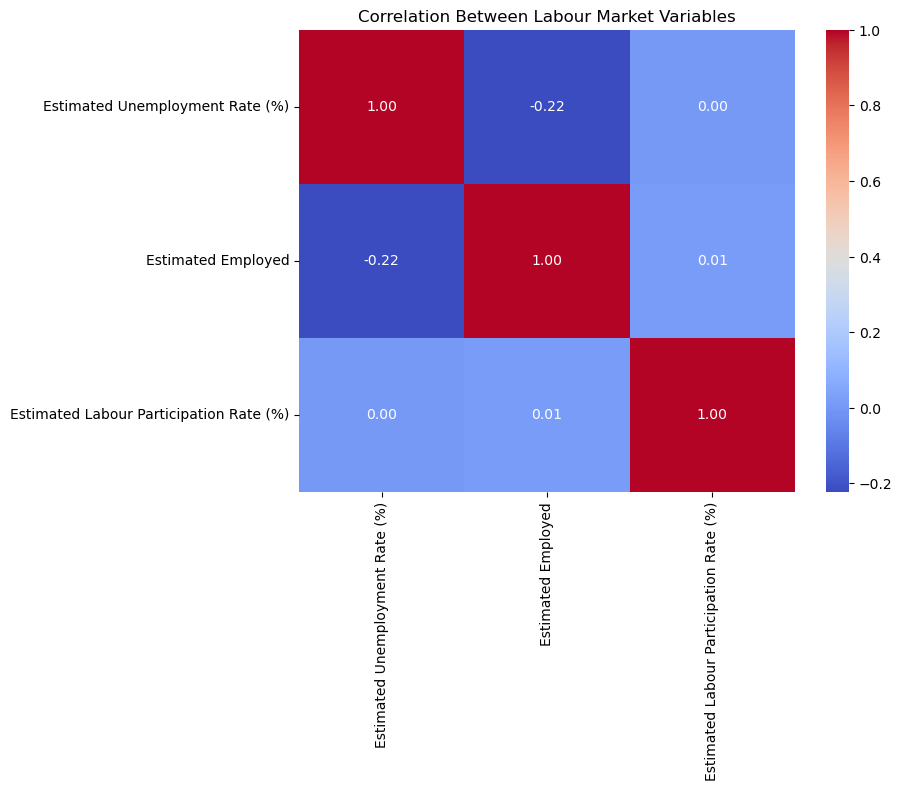

In [121]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Labour Market Variables")

plt.show()

In [122]:
highest = df.loc[
    df["Estimated Unemployment Rate (%)"].idxmax()
]

lowest = df.loc[
    df["Estimated Unemployment Rate (%)"].idxmin()
]


highest



Region                                              Puducherry
Date                                       2020-04-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                          76.74
Estimated Employed                                     68122.0
Estimated Labour Participation Rate (%)                  35.54
Area                                                     Urban
Year                                                      2020
Month                                                        4
Month_Name                                               April
COVID_Period                                      COVID Period
Name: 627, dtype: object

In [123]:
lowest

Region                                                   Assam
Date                                       2020-06-30 00:00:00
Frequency                                              Monthly
Estimated Unemployment Rate (%)                            0.0
Estimated Employed                                   7544937.0
Estimated Labour Participation Rate (%)                  34.38
Area                                                     Rural
Year                                                      2020
Month                                                        6
Month_Name                                                June
COVID_Period                                      COVID Period
Name: 25, dtype: object

In [124]:
highest_region = region_analysis.idxmax()
highest_region

'Tripura'

In [125]:
highest_region_rate = region_analysis.max()
highest_region_rate

28.350357142857142

In [126]:
lowest_region = region_analysis.idxmin()
lowest_region

'Meghalaya'

In [127]:
lowest_region_rate = region_analysis.min()
lowest_region_rate 

4.7988888888888885

In [128]:
df.to_csv(
    "cleaned_unemployment_data.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [129]:
region_analysis.to_csv(
    "regional_unemployment_analysis.csv"
)

print("Regional analysis saved!")

Regional analysis saved!


In [130]:
covid_analysis.to_csv(
    "covid_unemployment_analysis.csv",
    index=False
)

print("COVID analysis saved!")

COVID analysis saved!
